In [36]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Phần 1: Đọc và xử lý data từ file Excel
excel_file = "Data-Stata3.xlsx"   # bỏ khoảng trắng dư
sheets = pd.read_excel(excel_file, sheet_name=None)

# Tạo panel data
panel_data = []
years = ['2019', '2020', '2021', '2022', '2023']
for sheet_name, df in sheets.items():
    # Kiểm tra và sửa tên cột nếu cần (giả định cột đầu là Province)
    if df.columns[0] != 'Province':
        df.columns = ['Province'] + list(df.columns[1:])
    # Lấy các cột năm có trong sheet
    available_years = [col for col in df.columns if col in years]
    if not available_years:
        print(f"Sheet {sheet_name} không có cột năm nào, bỏ qua.")
        continue
    # Melt data
    melted = pd.melt(df, id_vars=['Province'], value_vars=available_years, var_name='Year', value_name=sheet_name)
    panel_data.append(melted)

# Gộp panel
if not panel_data:
    raise ValueError("Không có sheet nào có dữ liệu hợp lệ!")
df_panel = panel_data[0]
for df in panel_data[1:]:
    df_panel = pd.merge(df_panel, df, on=['Province', 'Year'], how='outer')

# Xử lý missing
numeric_cols = df_panel.columns[2:]
for col in numeric_cols:
    missing_rate = df_panel[col].isna().mean()
    if missing_rate > 0.5:
        print(f"Bỏ cột {col} do missing >30%")
        df_panel.drop(columns=[col], inplace=True)
    elif missing_rate > 0:
        mean_per_year = df_panel.groupby('Year')[col].transform('mean')
        df_panel[col] = df_panel[col].fillna(mean_per_year)

# Average theo tỉnh
df_avg = df_panel.groupby('Province').mean(numeric_only=True).reset_index()

# Kiểm tra số tỉnh
print(f"Tổng số tỉnh/thành: {len(df_avg)}")
print("Danh sách tỉnh:", df_avg['Province'].tolist())

# Scale data
numeric_cols = df_avg.columns[1:]  # Bỏ cột Province, lấy hết các cột numeric còn lại
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_avg[numeric_cols])
df_scaled = pd.DataFrame(scaled_data, columns=numeric_cols, index=df_avg['Province'])

# In đầy đủ dữ liệu scale
print("Dữ liệu scale đầy đủ:")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print(df_scaled.to_string())

Tổng số tỉnh/thành: 64
Danh sách tỉnh: ['An Giang', 'Bà Rịa - Vũng Tàu', 'Bình Dương', 'Bình Phước', 'Bình Thuận', 'Bình Định', 'Bạc Liêu', 'Bắc Giang', 'Bắc Kạn', 'Bắc Ninh', 'Bến Tre', 'Cao Bằng', 'Cà Mau', 'Cần Thơ', 'Gia Lai', 'Hoà Bình', 'Hà Giang', 'Hà Nam', 'Hà Nội', 'Hà Tĩnh', 'Hưng Yên', 'Hải Dương', 'Hải Phòng', 'Hậu Giang', 'Khánh Hoà', 'Kiên Giang', 'Kon Tum', 'Lai Châu', 'Long An', 'Lào Cai', 'Lâm Đồng', 'Lạng Sơn', 'Nam Định', 'Nghệ An', 'Ninh Bình', 'Ninh Thuận', 'Phú Thọ', 'Phú Yên', 'Quảng Bình', 'Quảng Nam', 'Quảng Ngãi', 'Quảng Ninh', 'Quảng Trị', 'Sóc Trăng', 'Sơn La', 'TP.Hồ Chí Minh', 'Thanh Hoá', 'Thái Bình', 'Thái Nguyên', 'Thừa Thiên Huế', 'Tiền Giang', 'Trà Vinh', 'Tuyên Quang', 'Tây Nguyên', 'Tây Ninh', 'Vĩnh Long', 'Vĩnh Phúc', 'Yên Bái', 'Điện Biên', 'Đà Nẵng', 'Đắk Lắk', 'Đắk Nông', 'Đồng Nai', 'Đồng Tháp']
Dữ liệu scale đầy đủ:
                   Mật độ dân số  Tuổi thọ trung bình  Tỷ lệ thất nghiệp  GDP_người  Doanh nghiệp_1000ng  Thu nhập du lịch  Thu n

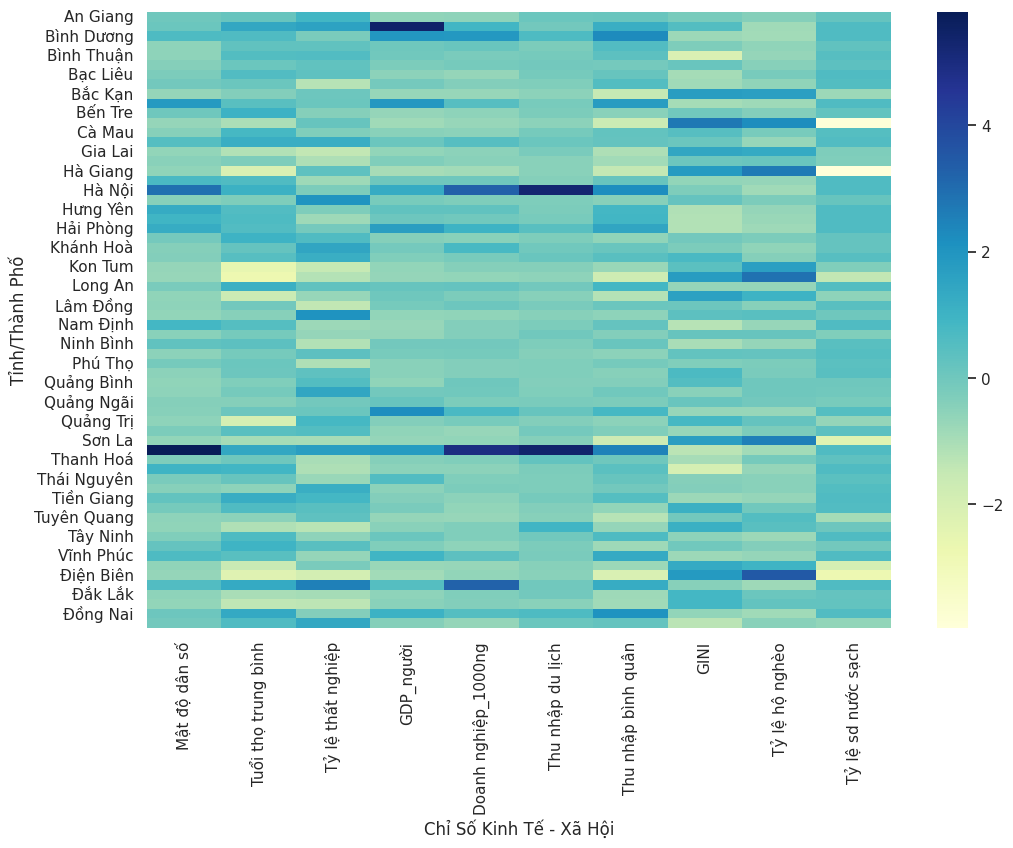

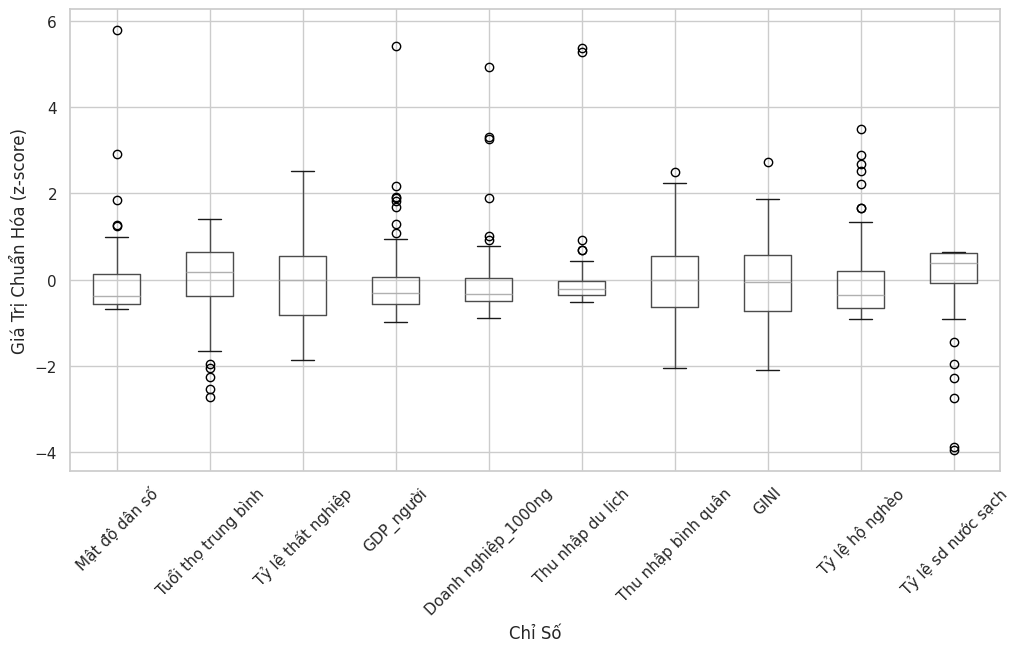

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Hình Heatmap Trung Bình Chỉ Số Theo Tỉnh
plt.figure(figsize=(12, 8))
sns.heatmap(df_scaled, cmap='YlGnBu', annot=False)
plt.xlabel('Chỉ Số Kinh Tế - Xã Hội')
plt.ylabel('Tỉnh/Thành Phố')
plt.savefig('heatmap_describe.png')
plt.show()

# Hình Boxplot Các Chỉ Số
plt.figure(figsize=(12, 6))
df_scaled.boxplot()
plt.xlabel('Chỉ Số')
plt.ylabel('Giá Trị Chuẩn Hóa (z-score)')
plt.xticks(rotation=45)
plt.savefig('boxplot_describe.png')
plt.show()

